In [ ]:
# Khai báo thư viện
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs

In [ ]:
# Tạo dữ liệu mẫu ngẫu nhiên (15 mẫu dữ liệu)
X, y = make_blobs(n_samples=15, centers=3, random_state=42)

In [ ]:
# Thực hiện phân cụm phân cấp tăng dần "ward" là phương pháp liên kết tổng thể
Z = linkage(X, method='ward')

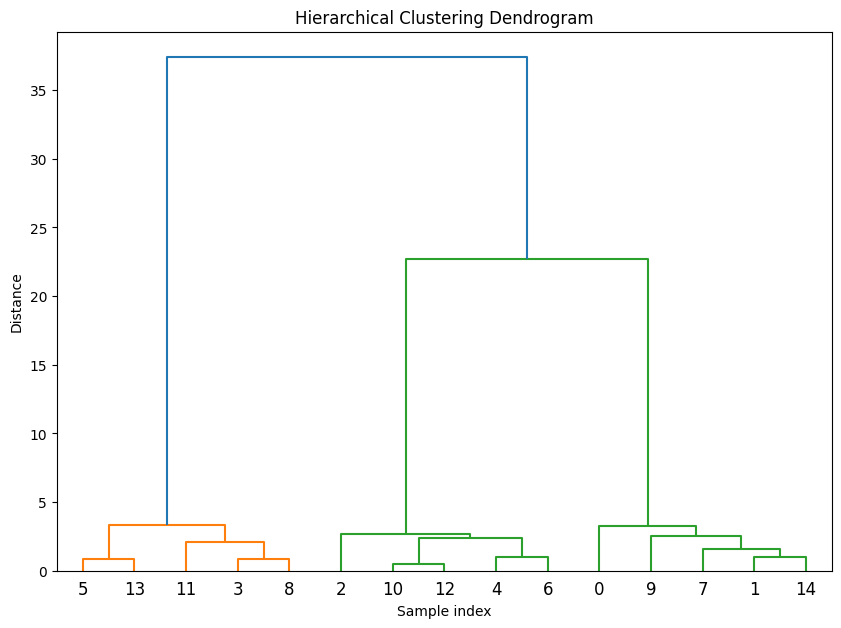

In [ ]:
# Vẽ dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

In [ ]:
# Thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster

In [ ]:
# Tạo tập dữ liệu mẫu (có thể đọc file dữ liệu dạng csv) giả định với 2 thuộc tính: Tuổi và Lương
np.random.seed(42)
age = np.random.randint(25, 60, size=20) # Tuổi từ 25 đến 60
salary = np.random.randint(50000, 150000, size=20) # Lương từ 50,000 đến 150,000

In [ ]:
# Tạo DataFrame để chứa dữ liệu
data = pd.DataFrame({'Age': age, 'Salary': salary})
# Hiển thị dữ liệu mẫu
print(data.head())

   Age  Salary
0   53  121932
1   39  143016
2   32   75658
3   45  134478
4   43   68431


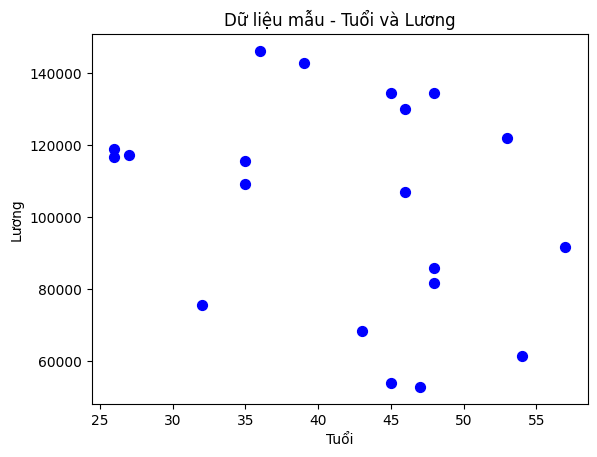

In [ ]:
# Trực quan hóa dữ liệu
plt.scatter(data['Age'], data['Salary'], color='blue', marker='o', s=50)
plt.title("Dữ liệu mẫu - Tuổi và Lương")
plt.xlabel("Tuổi")
plt.ylabel("Lương")
plt.show()

In [ ]:
# Phân cụm phân cấp tăng dần, sử dụng phương pháp 'ward' để tính khoảng cách
Z = linkage(data, method='ward')

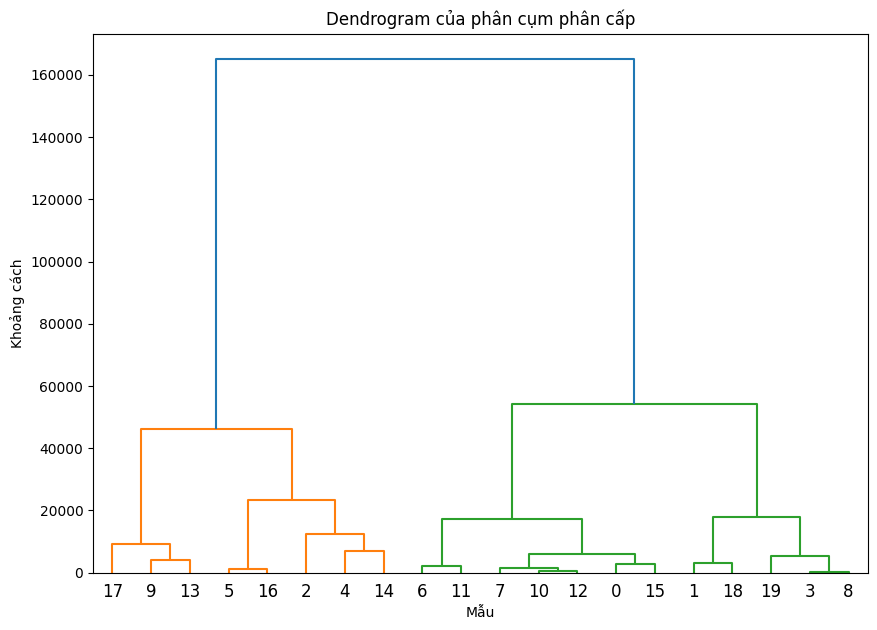

In [ ]:
# Trực quan hóa bằng dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=data.index.tolist())
plt.title("Dendrogram của phân cụm phân cấp")
plt.xlabel("Mẫu")
plt.ylabel("Khoảng cách")
plt.show()

In [ ]:
# Chọn số cụm bằng cách cắt cây dendrogram tại ngưỡng khoảng cách
max_distance = 70000 # Ngưỡng khoảng cách (có thể điều chỉnh)
clusters = fcluster(Z, max_distance, criterion='distance')

    Age  Salary  Cluster
0    53  121932        2
1    39  143016        2
2    32   75658        1
3    45  134478        2
4    43   68431        1
5    47   52747        1
6    35  109150        2
7    35  115725        2
8    48  134654        2
9    48   85773        1
10   27  117435        2
11   46  106886        2
12   26  116803        2
13   48   81551        1
14   54   61394        1
15   26  119092        2
16   45   53890        1
17   57   91606        1
18   36  146276        2
19   46  130038        2


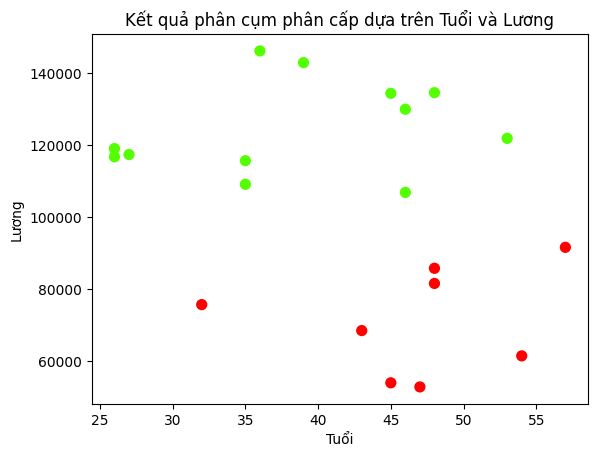

In [ ]:
# Thêm kết quả phân cụm vào DataFrame
data['Cluster'] = clusters
# Hiển thị dữ liệu sau khi phân cụm
print(data)
# Hiển thị dữ liệu sau phân cụm
plt.scatter(data['Age'], data['Salary'], c=data['Cluster'], cmap='prism', marker='o',
s=50)
plt.title("Kết quả phân cụm phân cấp dựa trên Tuổi và Lương")
plt.xlabel("Tuổi")
plt.ylabel("Lương")
plt.show()

In [ ]:
# Thư viện
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [ ]:
# Tạo dữ liệu mẫu với 300 điểm và 4 cụm
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60,
random_state=0)

/tmp/ipython-input-3020827092.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')


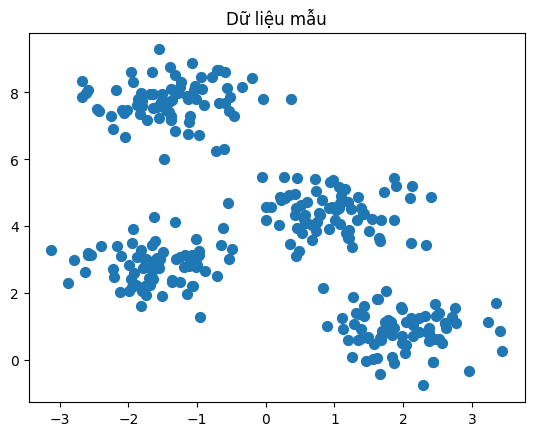

In [ ]:
# Hiển thị dữ liệu bằng biểu đồ phân tán
plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')
plt.title("Dữ liệu mẫu")
plt.show()

In [ ]:
# Khởi tạo và huấn luyện mô hình KMeans với số cụm K = 3
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

KMeans(n_clusters=3)

In [ ]:
# Dự đoán cụm cho mỗi điểm dữ liệu
y_kmeans = kmeans.predict(X)

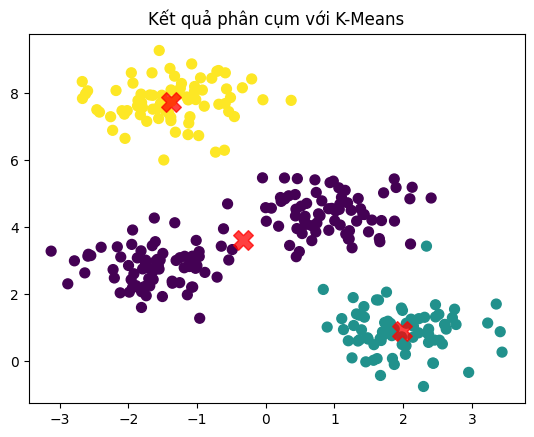

In [ ]:
# Trực quan hóa kết quả phân cụm
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
# Hiển thị tâm cụm
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title("Kết quả phân cụm với K-Means")
plt.show()

In [ ]:
# Dùng phương pháp Elbow để xác định K
sse = []
k_range = range(1, 11)
for k in k_range:
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X)
  sse.append(kmeans.inertia_) # inertia_ là tổng bình phương khoảng cách của các điểm đến tâm cụm của chúng

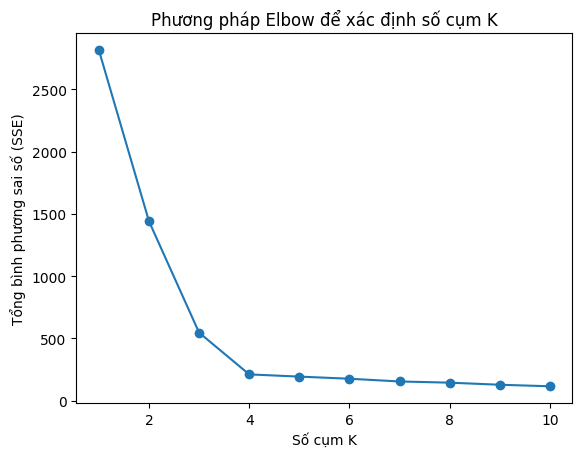

In [ ]:
# Vẽ biểu đồ Elbow
plt.plot(k_range, sse, marker='o')
plt.xlabel("Số cụm K")
plt.ylabel("Tổng bình phương sai số (SSE)")
plt.title("Phương pháp Elbow để xác định số cụm K")
plt.show()

**BÀI TẬP Ở LỚP**

**BÀI 1**

In [ ]:
import pandas as pd
import numpy as np

# tạo dữ liệu mẫu
np.random.seed(42)

age = np.random.randint(20, 60, 50)
income = np.random.randint(20, 100, 50)
credit = np.random.randint(500, 850, 50)

df = pd.DataFrame({
    "Age": age,
    "Income": income,
    "CreditScore": credit
})

print(df.head())


   Age  Income  CreditScore
0   58      55          547
1   48      69          561
2   34      23          715
3   27      21          792
4   40      25          598


In [ ]:
from scipy.cluster.hierarchy import linkage

X = df[["Age", "Income", "CreditScore"]].values

# single, complete, ward, average...
Z = linkage(X, method="ward")


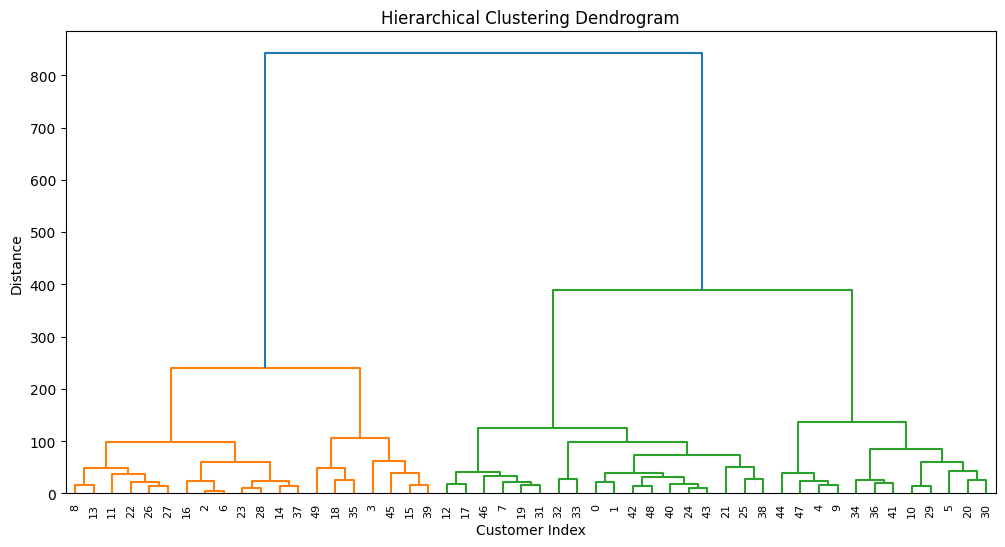

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.show()


In [ ]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=3, criterion='maxclust')
df["Cluster"] = clusters
print(df.head())


   Age  Income  CreditScore  Cluster
0   58      55          547        2
1   48      69          561        2
2   34      23          715        1
3   27      21          792        1
4   40      25          598        3


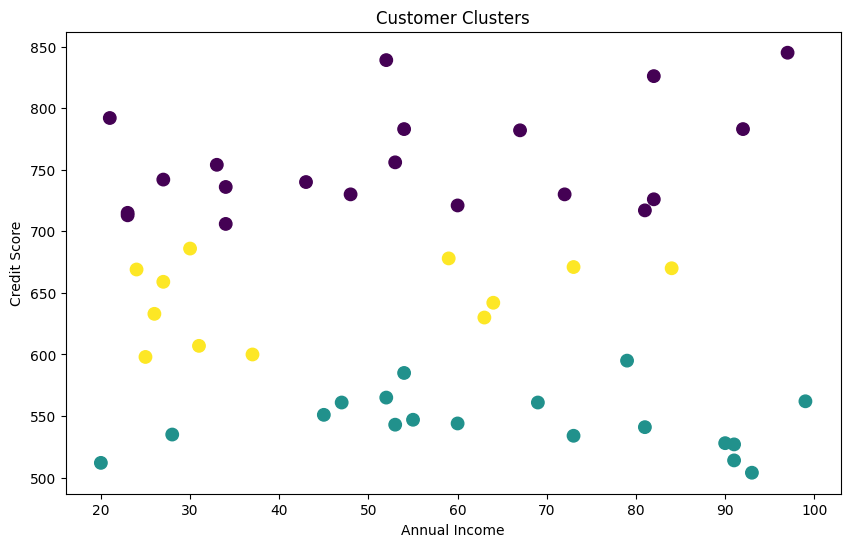

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Income"], df["CreditScore"], c=df["Cluster"], s=80)
plt.title("Customer Clusters")
plt.xlabel("Annual Income")
plt.ylabel("Credit Score")
plt.show()


**BÀI 2**

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Tạo dữ liệu 40 sinh viên
toan = np.random.randint(5, 10, 40)
vat_ly = np.random.randint(5, 10, 40)
hoa_hoc = np.random.randint(5, 10, 40)
sinh_hoc = np.random.randint(5, 10, 40)

df = pd.DataFrame({
    "Toán": toan,
    "Vật lý": vat_ly,
    "Hóa học": hoa_hoc,
    "Sinh học": sinh_hoc
})

print(df.head())


   Toán  Vật lý  Hóa học  Sinh học
0     8       8        9         6
1     9       5        5         8
2     7       8        9         9
3     9       6        9         7
4     9       6        5         5


In [ ]:
from scipy.cluster.hierarchy import linkage

X = df[["Toán", "Vật lý", "Hóa học", "Sinh học"]].values

Z = linkage(X, method="ward")


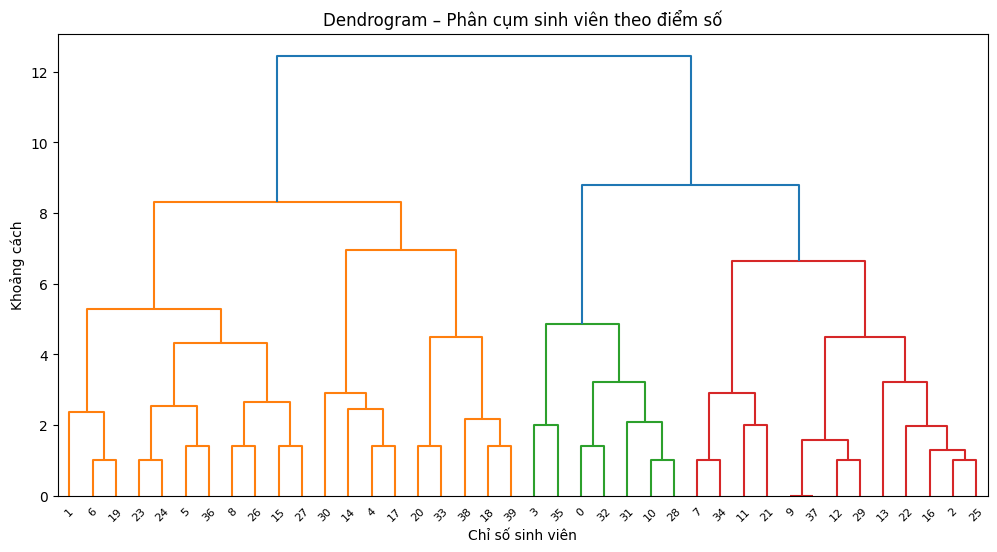

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Dendrogram – Phân cụm sinh viên theo điểm số")
plt.xlabel("Chỉ số sinh viên")
plt.ylabel("Khoảng cách")
plt.show()


In [ ]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=3, criterion='maxclust')
df["Cụm"] = clusters

print(df.head())


   Toán  Vật lý  Hóa học  Sinh học  Cụm
0     8       8        9         6    2
1     9       5        5         8    1
2     7       8        9         9    3
3     9       6        9         7    2
4     9       6        5         5    1


In [ ]:
for c in sorted(df["Cụm"].unique()):
    print(f"\n----- Cụm {c} -----")
    print(df[df["Cụm"] == c])



----- Cụm 1 -----
    Toán  Vật lý  Hóa học  Sinh học  Cụm
1      9       5        5         8    1
4      9       6        5         5    1
5      6       5        5         8    1
6      7       6        5         9    1
8      7       6        8         9    1
14     8       7        5         7    1
15     6       5        7         7    1
17     9       6        6         6    1
18     5       8        6         6    1
19     8       6        5         9    1
20     6       6        8         5    1
23     5       6        6         8    1
24     5       6        5         8    1
26     7       6        7         8    1
27     6       6        8         7    1
30     7       5        5         5    1
33     5       6        7         5    1
36     7       5        6         8    1
38     5       8        5         5    1
39     6       8        6         7    1

----- Cụm 2 -----
    Toán  Vật lý  Hóa học  Sinh học  Cụm
0      8       8        9         6    2
3      9       6   

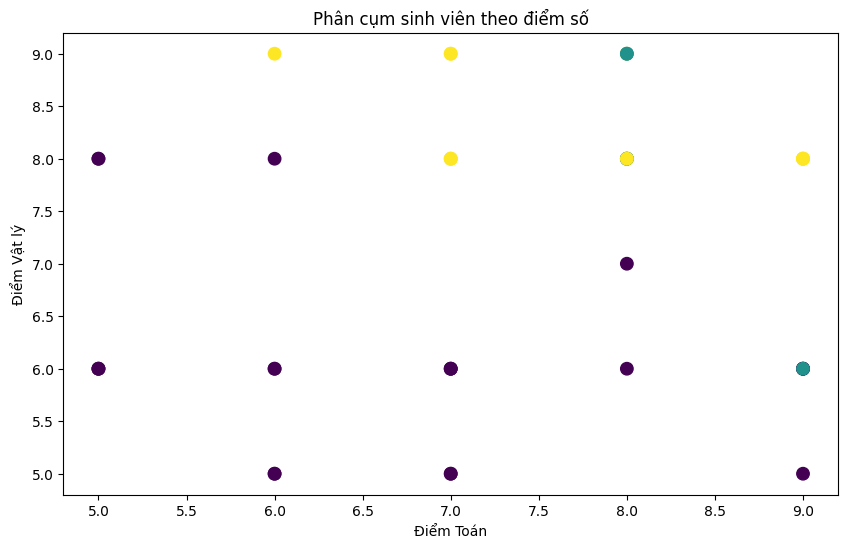

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Toán"], df["Vật lý"], c=df["Cụm"], s=80)
plt.title("Phân cụm sinh viên theo điểm số")
plt.xlabel("Điểm Toán")
plt.ylabel("Điểm Vật lý")
plt.show()


**BÀI 3:**

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

cities = ["Hà Nội", "TP.HCM", "Đà Nẵng", "Hải Phòng", "Cần Thơ",
          "Nha Trang", "Huế", "Vinh", "Quy Nhơn", "Đà Lạt"]

gdp = np.random.randint(3000000, 15000000, len(cities))            # GDP bình quân đầu người
life_quality = np.random.randint(50, 100, len(cities))        # Mức sống (điểm 0–100)
unemployment = np.random.uniform(2, 10, len(cities))          # Tỷ lệ thất nghiệp %
education = np.random.randint(40, 100, len(cities))           # Giáo dục (0–100)

df = pd.DataFrame({
    "Thành phố": cities,
    "GDP": gdp,
    "Mức sống": life_quality,
    "Thất nghiệp": unemployment,
    "Giáo dục": education
})

print(df)


   Thành phố       GDP  Mức sống  Thất nghiệp  Giáo dục
0     Hà Nội   9423388        52     4.433938        90
1     TP.HCM   9550634        71     6.198051        83
2    Đà Nẵng  13081351        51     5.455560        94
3  Hải Phòng   7304572        73     4.329833        91
4    Cần Thơ   5234489        93     6.894823        96
5  Nha Trang  12958614        79     3.115951        42
6        Huế  12524682        87     4.337157        76
7       Vinh  10204212        51     4.930895        90
8   Quy Nhơn  12628519        70     5.648560        46
9     Đà Lạt   7472471        82     8.281408        60


In [ ]:
from scipy.cluster.hierarchy import linkage

X = df[["GDP", "Mức sống", "Thất nghiệp", "Giáo dục"]].values

Z = linkage(X, method="ward")


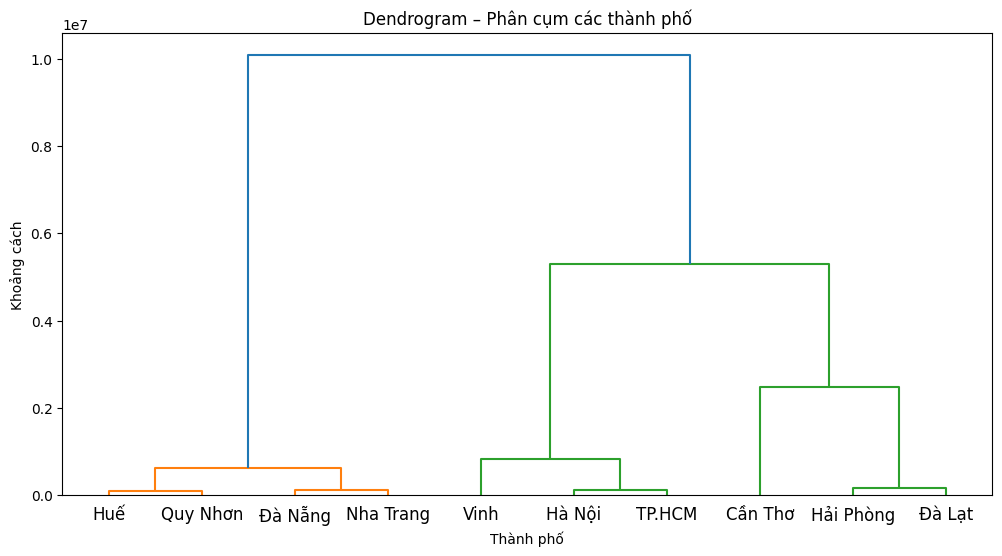

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df["Thành phố"].values)
plt.title("Dendrogram – Phân cụm các thành phố")
plt.xlabel("Thành phố")
plt.ylabel("Khoảng cách")
plt.show()


In [ ]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(Z, t=3, criterion="maxclust")
df["Cụm"] = clusters

print(df)


   Thành phố       GDP  Mức sống  Thất nghiệp  Giáo dục  Cụm
0     Hà Nội   9423388        52     4.433938        90    2
1     TP.HCM   9550634        71     6.198051        83    2
2    Đà Nẵng  13081351        51     5.455560        94    1
3  Hải Phòng   7304572        73     4.329833        91    3
4    Cần Thơ   5234489        93     6.894823        96    3
5  Nha Trang  12958614        79     3.115951        42    1
6        Huế  12524682        87     4.337157        76    1
7       Vinh  10204212        51     4.930895        90    2
8   Quy Nhơn  12628519        70     5.648560        46    1
9     Đà Lạt   7472471        82     8.281408        60    3


In [ ]:
for c in sorted(df["Cụm"].unique()):
    print(f"\n----- Cụm {c} -----")
    print(df[df["Cụm"] == c][["Thành phố", "GDP", "Mức sống", "Thất nghiệp", "Giáo dục"]])



----- Cụm 1 -----
   Thành phố       GDP  Mức sống  Thất nghiệp  Giáo dục
2    Đà Nẵng  13081351        51     5.455560        94
5  Nha Trang  12958614        79     3.115951        42
6        Huế  12524682        87     4.337157        76
8   Quy Nhơn  12628519        70     5.648560        46

----- Cụm 2 -----
  Thành phố       GDP  Mức sống  Thất nghiệp  Giáo dục
0    Hà Nội   9423388        52     4.433938        90
1    TP.HCM   9550634        71     6.198051        83
7      Vinh  10204212        51     4.930895        90

----- Cụm 3 -----
   Thành phố      GDP  Mức sống  Thất nghiệp  Giáo dục
3  Hải Phòng  7304572        73     4.329833        91
4    Cần Thơ  5234489        93     6.894823        96
9     Đà Lạt  7472471        82     8.281408        60


**BÀI 4:**

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

age = np.random.randint(18, 65, 50)
spending = np.random.randint(100, 1000, 50)

df = pd.DataFrame({
    "Tuổi": age,
    "Chi tiêu": spending
})

print(df.head())


   Tuổi  Chi tiêu
0    56       191
1    46       466
2    32       554
3    60       527
4    25       608


In [ ]:
from sklearn.cluster import KMeans

X = df[["Tuổi", "Chi tiêu"]].values

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

df["Cụm"] = labels
print(df.head())


   Tuổi  Chi tiêu  Cụm
0    56       191    1
1    46       466    0
2    32       554    0
3    60       527    0
4    25       608    0


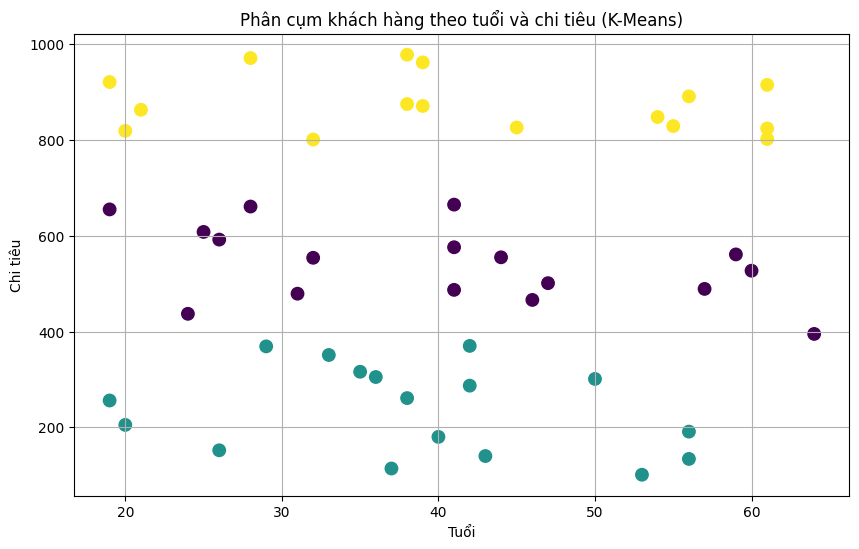

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["Tuổi"], df["Chi tiêu"], c=df["Cụm"], s=80)
plt.title("Phân cụm khách hàng theo tuổi và chi tiêu (K-Means)")
plt.xlabel("Tuổi")
plt.ylabel("Chi tiêu")
plt.grid(True)
plt.show()


In [ ]:
inertias = []
K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertias.append(model.inertia_)


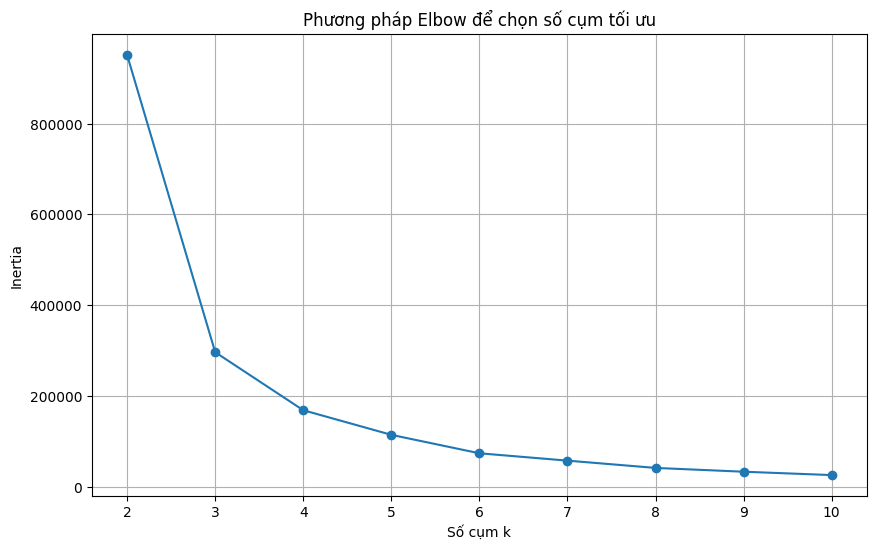

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(K, inertias, marker='o')
plt.title("Phương pháp Elbow để chọn số cụm tối ưu")
plt.xlabel("Số cụm k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [ ]:
optimal_kmeans = KMeans(n_clusters=3, random_state=42)
df["Cụm tối ưu"] = optimal_kmeans.fit_predict(X)
print(df)


    Tuổi  Chi tiêu  Cụm  Cụm tối ưu
0     56       191    1           1
1     46       466    0           0
2     32       554    0           0
3     60       527    0           0
4     25       608    0           0
5     38       875    2           2
6     56       134    1           1
7     36       305    1           1
8     40       180    1           1
9     28       661    0           0
10    28       971    2           2
11    41       487    0           0
12    53       101    1           1
13    57       489    0           0
14    41       665    0           0
15    20       205    1           1
16    39       871    2           2
17    19       921    2           2
18    41       576    0           0
19    61       802    2           2
20    47       501    0           0
21    55       829    2           2
22    19       655    0           0
23    38       261    1           1
24    50       301    1           1
25    29       369    1           1
26    39       962    2     

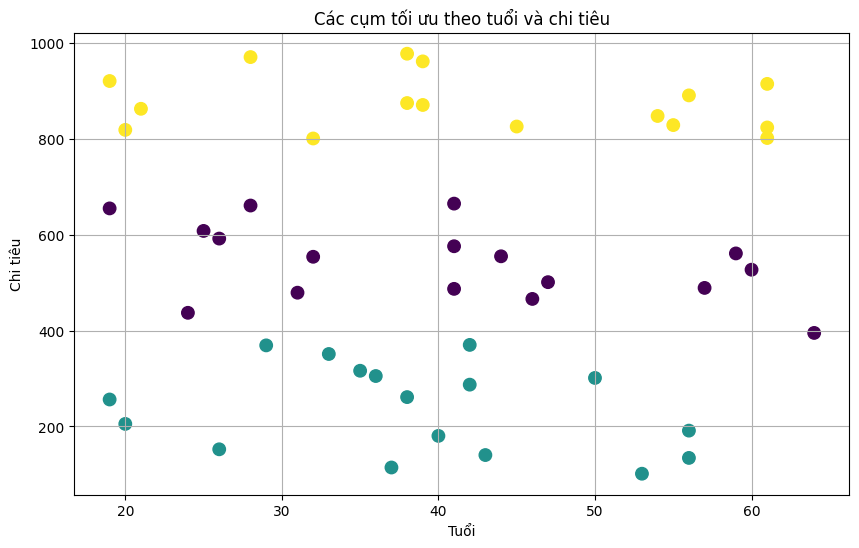

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Tuổi"], df["Chi tiêu"], c=df["Cụm tối ưu"], s=80)
plt.title("Các cụm tối ưu theo tuổi và chi tiêu")
plt.xlabel("Tuổi")
plt.ylabel("Chi tiêu")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.cluster import KMeans

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["Cụm"] = kmeans.fit_predict(df[["Tuổi", "Chi tiêu"]])


In [ ]:
for c in sorted(df["Cụm"].unique()):
    print(f"\n===== Cụm {c} =====")
    print(df[df["Cụm"] == c])



===== Cụm 0 =====
    Tuổi  Chi tiêu  Cụm  Cụm tối ưu
1     46       466    0           0
2     32       554    0           0
3     60       527    0           0
4     25       608    0           0
9     28       661    0           0
11    41       487    0           0
13    57       489    0           0
14    41       665    0           0
18    41       576    0           0
20    47       501    0           0
22    19       655    0           0
29    44       555    0           0
30    59       561    0           0
34    64       395    0           0
38    24       437    0           0
45    31       479    0           0
46    26       592    0           0

===== Cụm 1 =====
    Tuổi  Chi tiêu  Cụm  Cụm tối ưu
0     56       191    1           1
6     56       134    1           1
7     36       305    1           1
8     40       180    1           1
12    53       101    1           1
15    20       205    1           1
23    38       261    1           1
24    50       301    1   

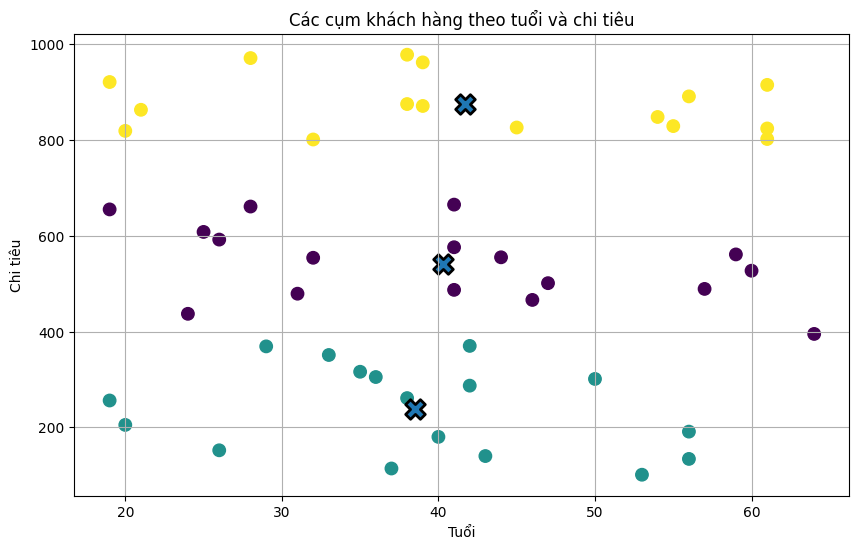

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(df["Tuổi"], df["Chi tiêu"], c=df["Cụm"], s=80)

# vẽ tâm cụm
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],
            marker="X", s=200, linewidths=2, edgecolor="black")

plt.title("Các cụm khách hàng theo tuổi và chi tiêu")
plt.xlabel("Tuổi")
plt.ylabel("Chi tiêu")
plt.grid(True)
plt.show()


In [ ]:
summary = df.groupby("Cụm")[["Tuổi", "Chi tiêu"]].mean()
print(summary)


          Tuổi    Chi tiêu
Cụm                       
0    40.294118  541.647059
1    38.529412  237.235294
2    41.687500  874.750000


**BÀI 5:**

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

products = [f"Sản phẩm {i}" for i in range(1, 100)]

quality = np.random.randint(1, 10, 99)      # Chất lượng
price = np.random.randint(1, 10, 99)        # Giá cả
design = np.random.randint(1, 10, 99)       # Mẫu mã
durability = np.random.randint(1, 10, 99)   # Độ bền

df = pd.DataFrame({
    "Sản phẩm": products,
    "Chất lượng": quality,
    "Giá cả": price,
    "Mẫu mã": design,
    "Độ bền": durability
})

print(df)


       Sản phẩm  Chất lượng  Giá cả  Mẫu mã  Độ bền
0    Sản phẩm 1           7       1       2       7
1    Sản phẩm 2           4       3       8       2
2    Sản phẩm 3           8       5       1       2
3    Sản phẩm 4           5       3       9       1
4    Sản phẩm 5           7       1       9       8
..          ...         ...     ...     ...     ...
94  Sản phẩm 95           5       4       3       4
95  Sản phẩm 96           3       9       8       8
96  Sản phẩm 97           8       1       8       7
97  Sản phẩm 98           6       8       2       2
98  Sản phẩm 99           3       7       6       1

[99 rows x 5 columns]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df[["Chất lượng", "Giá cả", "Mẫu mã", "Độ bền"]])


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cụm"] = kmeans.fit_predict(X)

print(df)


       Sản phẩm  Chất lượng  Giá cả  Mẫu mã  Độ bền  Cụm
0    Sản phẩm 1           7       1       2       7    0
1    Sản phẩm 2           4       3       8       2    2
2    Sản phẩm 3           8       5       1       2    0
3    Sản phẩm 4           5       3       9       1    2
4    Sản phẩm 5           7       1       9       8    2
..          ...         ...     ...     ...     ...  ...
94  Sản phẩm 95           5       4       3       4    1
95  Sản phẩm 96           3       9       8       8    1
96  Sản phẩm 97           8       1       8       7    2
97  Sản phẩm 98           6       8       2       2    0
98  Sản phẩm 99           3       7       6       1    2

[99 rows x 6 columns]


In [ ]:
cluster_summary = df.groupby("Cụm")[["Chất lượng", "Giá cả", "Mẫu mã", "Độ bền"]].mean()
print(cluster_summary)


     Chất lượng  Giá cả    Mẫu mã    Độ bền
Cụm                                        
0      7.861111    5.75  4.083333  5.000000
1      3.057143    4.80  2.914286  5.685714
2      5.035714    3.50  7.571429  3.714286


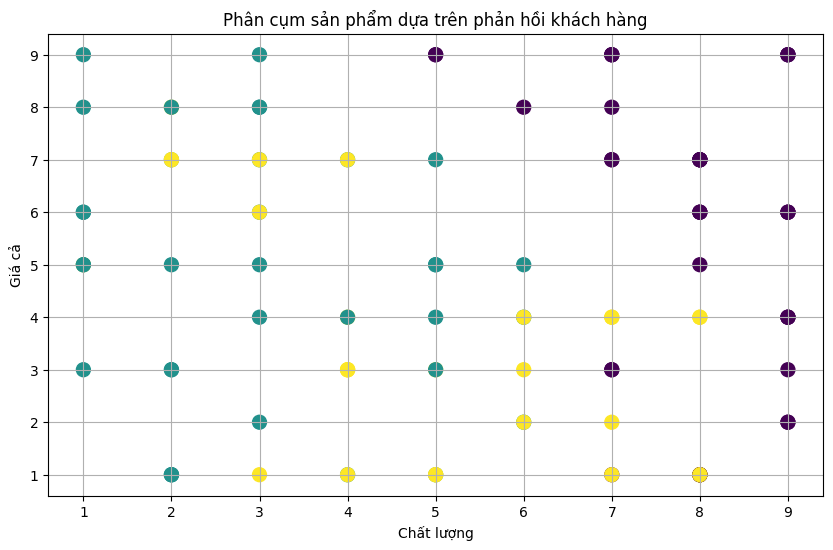

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["Chất lượng"], df["Giá cả"], c=df["Cụm"], s=100)
plt.title("Phân cụm sản phẩm dựa trên phản hồi khách hàng")
plt.xlabel("Chất lượng")
plt.ylabel("Giá cả")
plt.grid(True)
plt.show()


**BÀI TẬP VỀ NHÀ**

**BÀI 1**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

In [ ]:
# Thiết lập hiển thị cho đồ thị
plt.style.use('seaborn-v0_8-whitegrid')

# 1. TẠO DỮ LIỆU GIẢ ĐỊNH (Thay thế bằng dữ liệu thực tế của doanh nghiệp)
data = {
    'Frequency': [10, 2, 6, 8, 1, 12, 5, 9, 3, 7, 11, 4, 9, 1, 6],
    'Avg_Spend': [1000, 200, 500, 750, 150, 1200, 450, 850, 250, 600, 1100, 300, 950, 180, 550],
    'Product_Cat': [1, 3, 2, 1, 3, 1, 2, 1, 3, 1, 1, 3, 1, 3, 2] # Mã hóa: 1=A, 2=B, 3=C
}
df = pd.DataFrame(data)

# Lưu lại bản gốc để sử dụng cho bước phân tích cuối cùng
df_original = df.copy()

print("--- Dữ liệu Gốc (Các thuộc tính) ---")
print(df)

--- Dữ liệu Gốc (Các thuộc tính) ---
    Frequency  Avg_Spend  Product_Cat
0          10       1000            1
1           2        200            3
2           6        500            2
3           8        750            1
4           1        150            3
5          12       1200            1
6           5        450            2
7           9        850            1
8           3        250            3
9           7        600            1
10         11       1100            1
11          4        300            3
12          9        950            1
13          1        180            3
14          6        550            2


In [ ]:
# 2. CHUẨN HÓA DỮ LIỆU (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7909 (\N{LATIN SMALL LETTER U WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 431 (\N{LATIN CAPITAL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7899 (\N{LATIN SMALL LETTER O

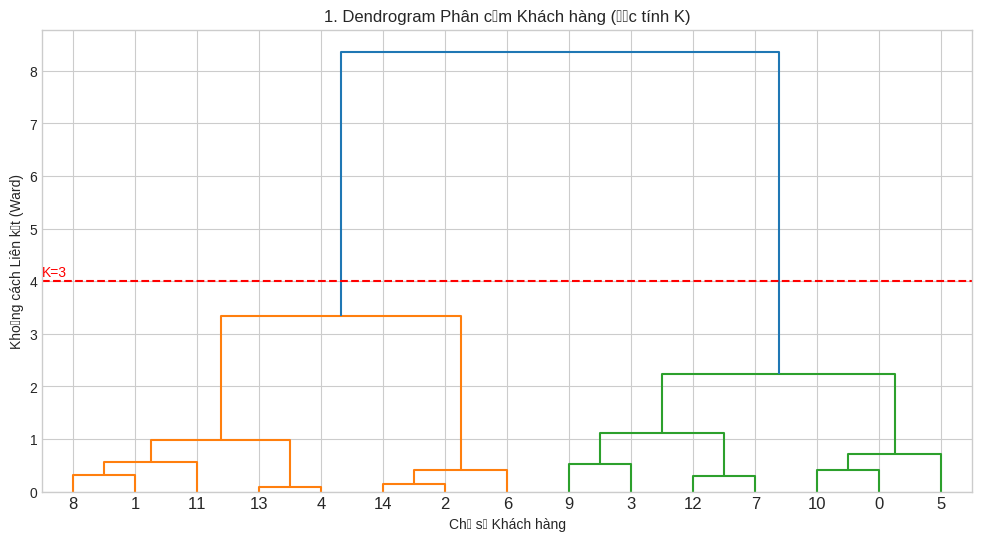

In [ ]:
# 3. XÂY DỰNG DENDROGRAM VÀ CHỌN K TỐI ƯU (Yêu cầu 2)
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('1. Dendrogram Phân cụm Khách hàng (Ước tính K)')
plt.xlabel('Chỉ số Khách hàng')
plt.ylabel('Khoảng cách Liên kết (Ward)')
plt.axhline(y=4.0, color='r', linestyle='--')
plt.text(0, 4.1, 'K=3', color='red')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7875 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7891 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7885 (\N{LATIN SMALL LETTER O WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: G

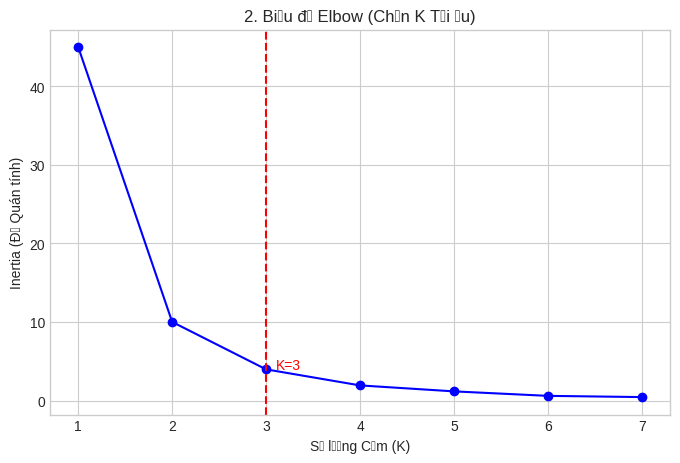

In [ ]:
# === 3b. Biểu đồ Elbow (Xác nhận K) ===
# Tính Inertia (Tổng bình phương khoảng cách) cho các giá trị K khác nhau
inertia = []
k_range = range(1, 8)
for k in k_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(X_scaled)
    inertia.append(kmeans_model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='-', color='blue')
plt.title('2. Biểu đồ Elbow (Chọn K Tối ưu)')
plt.xlabel('Số lượng Cụm (K)')
plt.ylabel('Inertia (Độ Quán tính)')
# Điểm 'khuỷu tay' (Elbow point) thường là nơi đường cong bắt đầu phẳng hơn (tại K=3)
plt.axvline(x=3, color='red', linestyle='--')
plt.text(3.1, inertia[2], 'K=3', color='red')
plt.show()

# Xác định số cụm K
k = 3

In [ ]:
# 4. THỰC HIỆN PHÂN CỤM K-MEANS (Yêu cầu 1)
print(f"\n--- Thực hiện K-Means với K = {k} ---")

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_original['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Phân bổ khách hàng (Tổng {len(df_original)}):")
print(df_original['Cluster'].value_counts().sort_index())

# Đánh giá chất lượng phân cụm
score = silhouette_score(X_scaled, df_original['Cluster'])
print(f"\nSilhouette Score cho K={k}: {score:.4f} (Càng gần 1 càng tốt)")



--- Thực hiện K-Means với K = 3 ---
Phân bổ khách hàng (Tổng 15):
Cluster
0    5
1    6
2    4
Name: count, dtype: int64

Silhouette Score cho K=3: 0.6083 (Càng gần 1 càng tốt)


In [ ]:
# 5. PHÂN TÍCH CÁC CỤM ĐỂ TÌM HÀNH VI TƯƠNG ĐỒNG
cluster_analysis = df_original.groupby('Cluster').agg({
    'Frequency': ['mean', 'std'],
    'Avg_Spend': ['mean', 'std'],
    'Product_Cat': lambda x: x.mode()[0]
})
cluster_analysis.columns = ['Freq_Mean', 'Freq_Std', 'Spend_Mean', 'Spend_Std', 'Product_Mode']

print("\n--- KẾT QUẢ PHÂN TÍCH HÀNH VI CỦA CÁC CỤM ---")
print(cluster_analysis)


--- KẾT QUẢ PHÂN TÍCH HÀNH VI CỦA CÁC CỤM ---
         Freq_Mean  Freq_Std  Spend_Mean   Spend_Std  Product_Mode
Cluster                                                           
0         2.200000  1.303840       216.0   59.413803             3
1         9.833333  1.471960       975.0  163.554272             1
2         6.000000  0.816497       525.0   64.549722             2


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7873 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7895 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND TILDE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7883 (\N{LATIN SMALL LETTER I WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7921

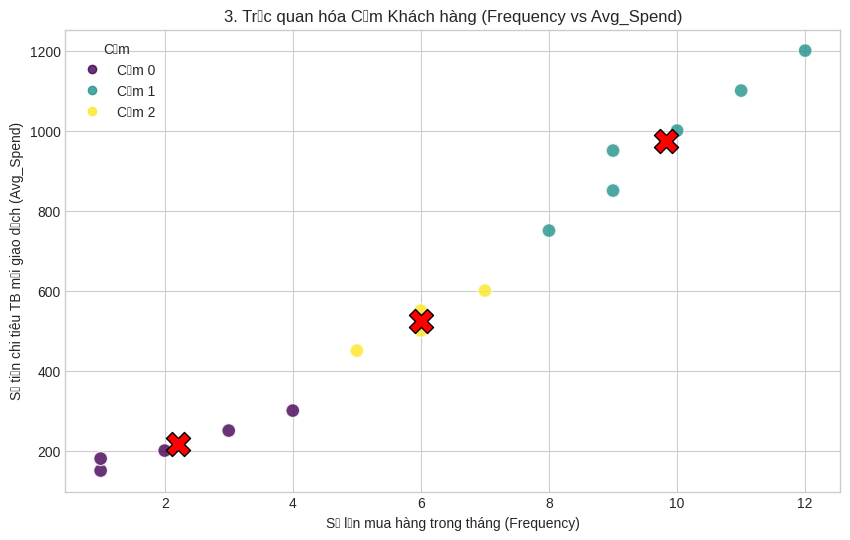

In [ ]:
plt.figure(figsize=(10, 6))
# Vẽ biểu đồ phân tán sử dụng 2 thuộc tính chính (Frequency và Avg_Spend)
scatter = plt.scatter(
    df_original['Frequency'],
    df_original['Avg_Spend'],
    c=df_original['Cluster'],
    cmap='viridis',
    s=100,
    alpha=0.8,
    edgecolors='w'
)
# Thêm tâm cụm (Centroids)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=300,
    c='red',
    label='Tâm Cụm (Centroids)',
    edgecolors='black'
)
plt.title('3. Trực quan hóa Cụm Khách hàng (Frequency vs Avg_Spend)')
plt.xlabel('Số lần mua hàng trong tháng (Frequency)')
plt.ylabel('Số tiền chi tiêu TB mỗi giao dịch (Avg_Spend)')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cụm {i}' for i in range(k)], title='Cụm')
plt.grid(True)
plt.show()

In [ ]:
print("\n--- DIỄN GIẢI VÀ CHIẾN LƯỢC TIẾP THỊ ---")

# (Phần giải thích không thay đổi vì nó dựa trên kết quả thống kê)
print("Cụm 0 (Khách hàng VIP):")
print("  Hành vi: Mua rất thường xuyên, chi tiêu rất lớn. Yêu thích sản phẩm loại A.")
print("  Chiến lược: Duy trì. Ưu đãi độc quyền, giới thiệu sớm sản phẩm A mới, chương trình thưởng cao cấp.")

print("\nCụm 1 (Khách hàng Tiết kiệm/Mới):")
print("  Hành vi: Tần suất và chi tiêu thấp nhất. Yêu thích sản phẩm loại C.")
print("  Chiến lược: Kích thích. Ưu đãi giảm giá/combo cho sản phẩm C, chiến dịch tái kích hoạt mua hàng (win-back).")

print("\nCụm 2 (Khách hàng Trung thành Ổn định):")
print("  Hành vi: Mua đều đặn, chi tiêu vừa phải. Yêu thích sản phẩm loại B.")
print("  Chiến lược: Tăng trưởng. Khuyến khích Up-selling (nâng cấp sản phẩm B), Cross-selling các sản phẩm liên quan để tăng Avg_Spend.")


--- DIỄN GIẢI VÀ CHIẾN LƯỢC TIẾP THỊ ---
Cụm 0 (Khách hàng VIP):
  Hành vi: Mua rất thường xuyên, chi tiêu rất lớn. Yêu thích sản phẩm loại A.
  Chiến lược: Duy trì. Ưu đãi độc quyền, giới thiệu sớm sản phẩm A mới, chương trình thưởng cao cấp.

Cụm 1 (Khách hàng Tiết kiệm/Mới):
  Hành vi: Tần suất và chi tiêu thấp nhất. Yêu thích sản phẩm loại C.
  Chiến lược: Kích thích. Ưu đãi giảm giá/combo cho sản phẩm C, chiến dịch tái kích hoạt mua hàng (win-back).

Cụm 2 (Khách hàng Trung thành Ổn định):
  Hành vi: Mua đều đặn, chi tiêu vừa phải. Yêu thích sản phẩm loại B.
  Chiến lược: Tăng trưởng. Khuyến khích Up-selling (nâng cấp sản phẩm B), Cross-selling các sản phẩm liên quan để tăng Avg_Spend.


**BÀI 2:**

In [ ]:
# Bước 1: Chuẩn bị dữ liệu văn bản
import pandas as pd

docs = [
    "AI đang thay đổi cách thức làm việc trong ngành công nghệ thông tin.",
    "Học máy là một nhánh quan trọng của trí tuệ nhân tạo.",
    "Ngôn ngữ lập trình Python rất phổ biến trong khoa học dữ liệu.",
    "Môi trường tự nhiên đang bị biến đổi khí hậu ảnh hưởng.",
    "Động vật hoang dã cần được bảo vệ khỏi săn bắt trái phép.",
    "Biến đổi khí hậu ảnh hưởng đến đa dạng sinh học.",
    "Python và R là hai ngôn ngữ phổ biến trong phân tích dữ liệu.",
    "Chương trình giáo dục giúp học sinh phát triển tư duy sáng tạo."
]

df = pd.DataFrame({"Văn bản": docs})

In [ ]:
# Bước 2: Chuyển văn bản thành vector (TF-IDF)
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["Văn bản"])

# Chuyển sang numpy array (không dùng np.matrix) để chuẩn hóa
X_array = X.toarray()

In [ ]:
# Bước 3: Chuẩn hóa vector
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_array)

In [ ]:
# Bước 4: Phân cụm phân cấp
# =========================
from scipy.cluster.hierarchy import linkage

Z = linkage(X_scaled, method="ward")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7909 (\N{LATIN SMALL LETTER U WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7853 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7847 (

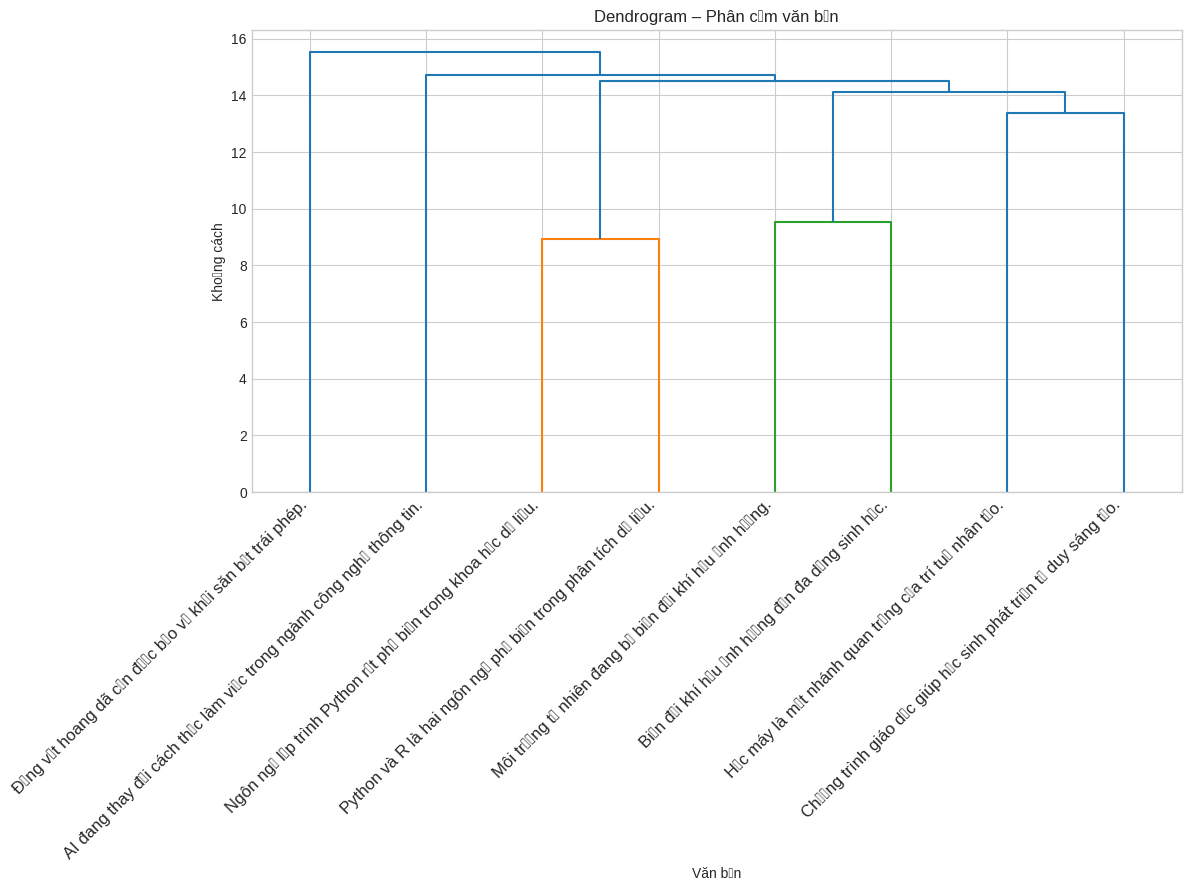

In [ ]:
# Bước 5: Vẽ dendrogram
# =========================
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12,6))
dendrogram(Z, labels=df["Văn bản"].values, orientation='top')
plt.title("Dendrogram – Phân cụm văn bản")
plt.xlabel("Văn bản")
plt.ylabel("Khoảng cách")
plt.xticks(rotation=45, ha="right")
plt.show()


In [ ]:
# Bước 6: Gom nhóm văn bản theo dendrogram
# =========================
from scipy.cluster.hierarchy import fcluster

# Giả sử chọn 3 cụm
df["Cụm"] = fcluster(Z, t=3, criterion="maxclust")
print("\nDữ liệu với cụm:")
print(df)


Dữ liệu với cụm:
                                             Văn bản  Cụm
0  AI đang thay đổi cách thức làm việc trong ngàn...    2
1  Học máy là một nhánh quan trọng của trí tuệ nh...    1
2  Ngôn ngữ lập trình Python rất phổ biến trong k...    1
3  Môi trường tự nhiên đang bị biến đổi khí hậu ả...    1
4  Động vật hoang dã cần được bảo vệ khỏi săn bắt...    3
5   Biến đổi khí hậu ảnh hưởng đến đa dạng sinh học.    1
6  Python và R là hai ngôn ngữ phổ biến trong phâ...    1
7  Chương trình giáo dục giúp học sinh phát triển...    1


In [ ]:
# Bước 7: Hiển thị nhóm văn bản theo cụm
# =========================
for c in sorted(df["Cụm"].unique()):
    print(f"\n===== Nhóm {c} =====")
    for doc in df[df["Cụm"] == c]["Văn bản"]:
        print("-", doc)



===== Nhóm 1 =====
- Học máy là một nhánh quan trọng của trí tuệ nhân tạo.
- Ngôn ngữ lập trình Python rất phổ biến trong khoa học dữ liệu.
- Môi trường tự nhiên đang bị biến đổi khí hậu ảnh hưởng.
- Biến đổi khí hậu ảnh hưởng đến đa dạng sinh học.
- Python và R là hai ngôn ngữ phổ biến trong phân tích dữ liệu.
- Chương trình giáo dục giúp học sinh phát triển tư duy sáng tạo.

===== Nhóm 2 =====
- AI đang thay đổi cách thức làm việc trong ngành công nghệ thông tin.

===== Nhóm 3 =====
- Động vật hoang dã cần được bảo vệ khỏi săn bắt trái phép.


In [ ]:
# Bước 8: Đánh giá chất lượng phân cụm
# =========================
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import cophenet

# Silhouette score
score = silhouette_score(X_scaled, df["Cụm"])
print("\nSilhouette Score:", score)

# Cophenetic correlation
c, coph_dists = cophenet(Z, pdist(X_scaled))
print("Cophenetic Correlation:", c)


Silhouette Score: 0.08192744722622321
Cophenetic Correlation: 0.8686339200313461


**BÀI 3:**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [ ]:
digits = load_digits()  # 8x8 ảnh grayscale
images = digits.images
labels_true = digits.target  # nhãn gốc (chỉ để tham khảo, không dùng phân cụm)

n_samples = images.shape[0]

# Chuyển mỗi ảnh thành vector đặc trưng (flatten)
X = images.reshape((n_samples, -1))  # mỗi ảnh 64 chiều

print("Kích thước ma trận đặc trưng:", X.shape)

Kích thước ma trận đặc trưng: (1797, 64)


In [ ]:
# Bước 2: Chuẩn hóa vector
# =========================
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

In [ ]:
# Bước 3: Phân cụm phân cấp
# =========================
from scipy.cluster.hierarchy import linkage

Z = linkage(X_scaled, method="ward")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7909 (\N{LATIN SMALL LETTER U WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7842 (\N{LATIN CAPITAL LETTER A WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


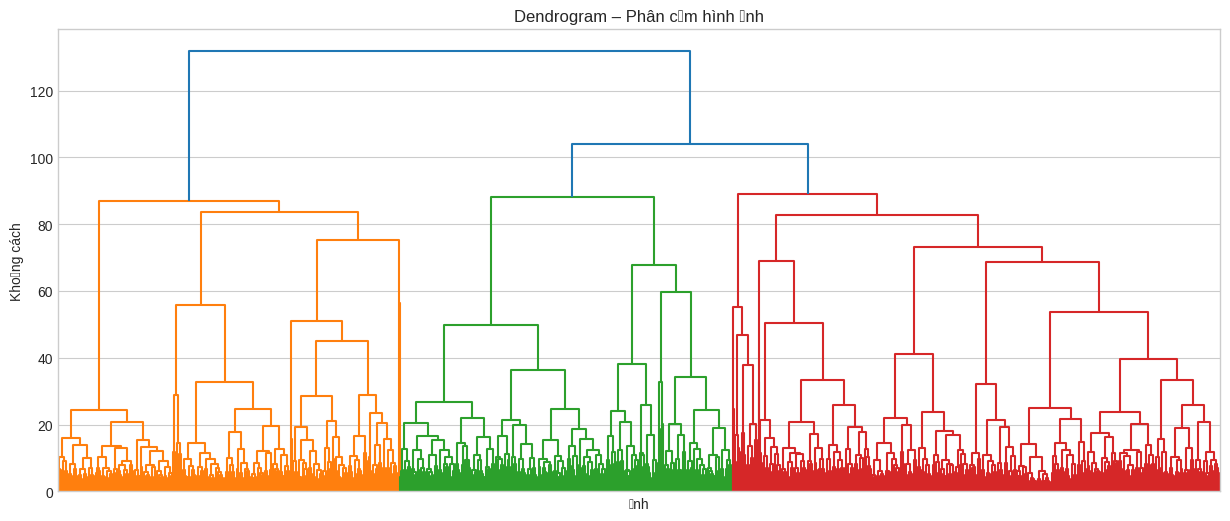

In [ ]:
# Bước 4: Vẽ dendrogram
# =========================
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(15, 6))
dendrogram(Z, truncate_mode='level', p=30, no_labels=True)  # truncate để vẽ dễ nhìn
plt.title("Dendrogram – Phân cụm hình ảnh")
plt.xlabel("Ảnh")
plt.ylabel("Khoảng cách")
plt.show()

In [ ]:
# Bước 5: Gom nhóm hình ảnh theo dendrogram
# =========================
from scipy.cluster.hierarchy import fcluster

# Giả sử chọn 10 cụm (vì MNIST digits có 10 chữ số)
clusters = fcluster(Z, t=10, criterion="maxclust")

# Lưu kết quả vào DataFrame
df_results = pd.DataFrame({
    "Ảnh_index": np.arange(n_samples),
    "Cluster": clusters,
    "True_Label": labels_true  # chỉ để so sánh, không dùng phân cụm
})

print(df_results.head(10))

   Ảnh_index  Cluster  True_Label
0          0        1           0
1          1       10           1
2          2       10           2
3          3        5           3
4          4        3           4
5          5        5           5
6          6        2           6
7          7        9           7
8          8       10           8
9          9        5           9



==== Cụm 1 (178 ảnh) ====


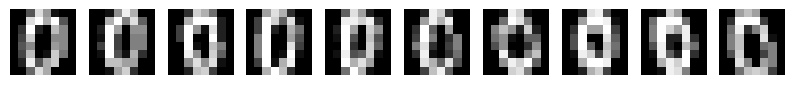


==== Cụm 2 (182 ảnh) ====


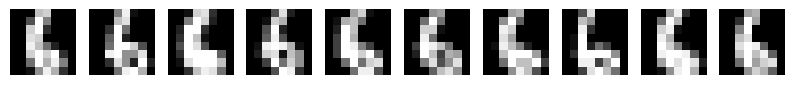


==== Cụm 3 (167 ảnh) ====


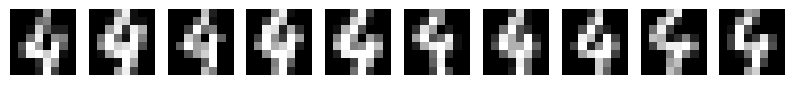


==== Cụm 4 (2 ảnh) ====


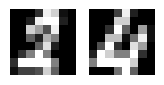


==== Cụm 5 (319 ảnh) ====


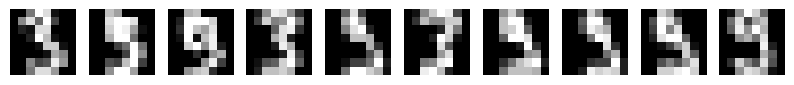


==== Cụm 6 (195 ảnh) ====


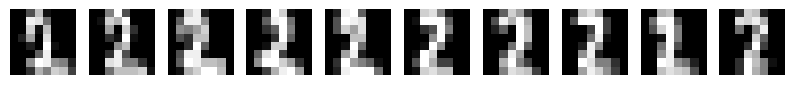


==== Cụm 7 (40 ảnh) ====


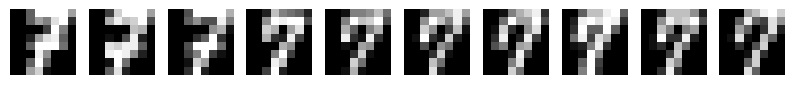


==== Cụm 8 (175 ảnh) ====


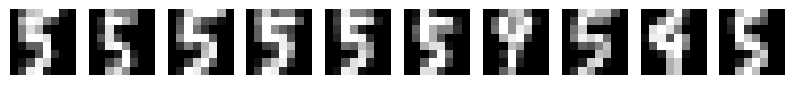


==== Cụm 9 (151 ảnh) ====


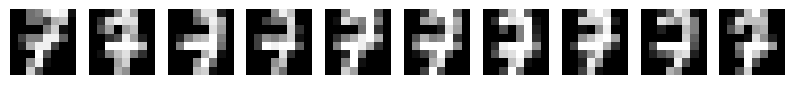


==== Cụm 10 (388 ảnh) ====


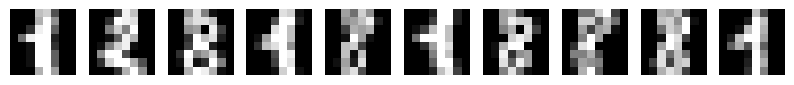

In [ ]:
# Bước 6: Hiển thị vài ảnh theo cụm
# =========================
import matplotlib.pyplot as plt

for c in range(1, 11):
    idx = np.where(clusters == c)[0]
    print(f"\n==== Cụm {c} ({len(idx)} ảnh) ====")
    plt.figure(figsize=(10,2))
    for i, img_idx in enumerate(idx[:10]):  # hiển thị tối đa 10 ảnh đầu của cụm
        plt.subplot(1,10,i+1)
        plt.imshow(images[img_idx], cmap='gray')
        plt.axis('off')
    plt.show()


In [ ]:
# Bước 7: Đánh giá chất lượng phân cụm
# =========================
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import cophenet

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

c, coph_dists = cophenet(Z, pdist(X_scaled))
print("Cophenetic Correlation:", c)


Silhouette Score: 0.12532527779196986
Cophenetic Correlation: 0.247610803995813


In [ ]:
# Bước 8: Lưu kết quả phân cụm ra CSV
# =========================
df_results.to_csv("image_clusters.csv", index=False)
print("Kết quả phân cụm đã lưu vào 'image_clusters.csv'")

Kết quả phân cụm đã lưu vào 'image_clusters.csv'


**BÀI 4**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score

In [ ]:
iris = load_iris()
X = iris.data  # các thuộc tính: sepal length, sepal width, petal length, petal width
y_true = iris.target  # nhãn loài thực tế
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['Loai_hoa'] = y_true

print("10 dòng đầu tiên của dữ liệu Iris:")
print(df.head(10))


10 dòng đầu tiên của dữ liệu Iris:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   Loai_hoa  
0         0  
1         0  
2         0  
3         0  
4         0  
5         0

In [ ]:
print("\nThông tin dữ liệu:")
print(df.info())



Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Loai_hoa           150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [ ]:
print("\nThống kê mô tả dữ liệu:")
print(df.describe())


Thống kê mô tả dữ liệu:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)    Loai_hoa  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7911 (\N{LATIN SMALL LETTER U WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


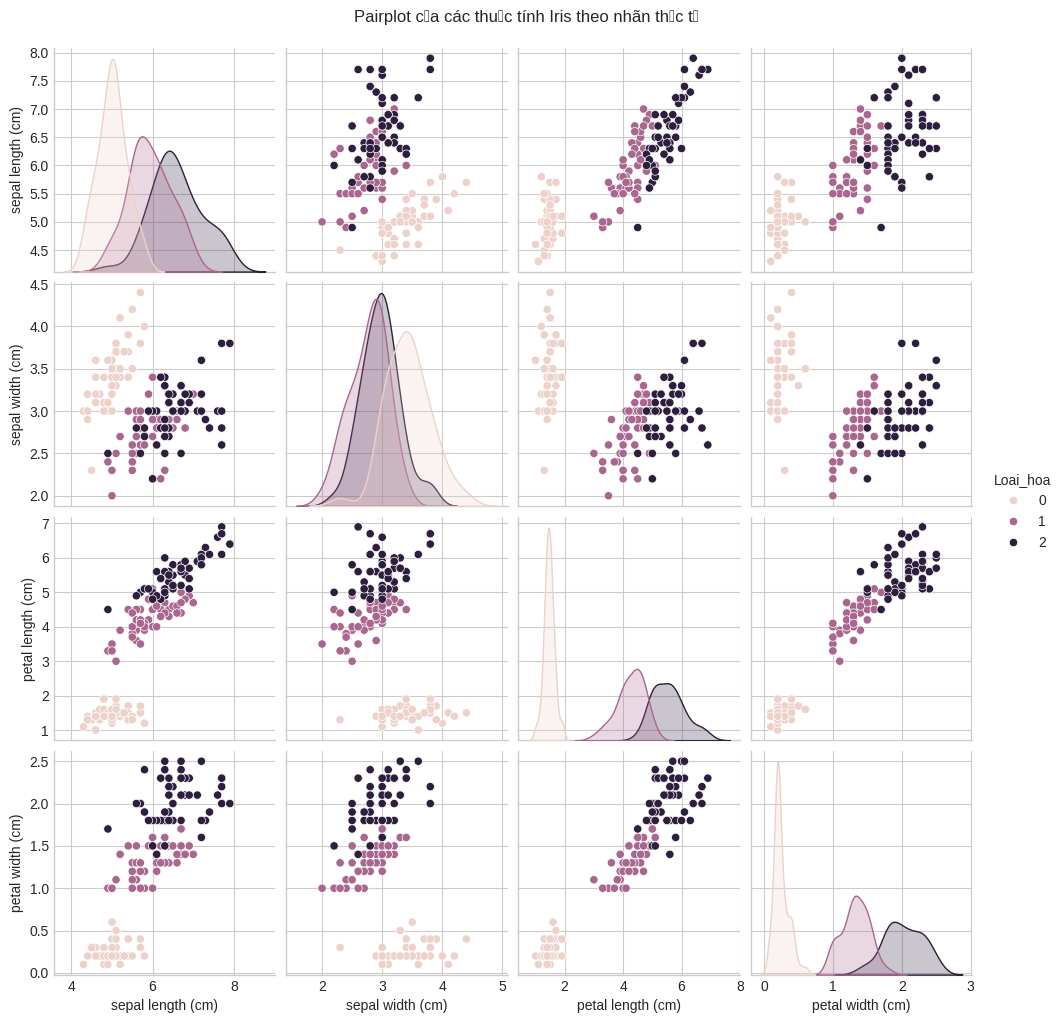

In [ ]:
# Trực quan hóa phân phối từng thuộc tính
sns.pairplot(df, hue='Loai_hoa', diag_kind='kde')
plt.suptitle("Pairplot của các thuộc tính Iris theo nhãn thực tế", y=1.02)
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
k = 3  # vì Iris có 3 loài
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)
y_kmeans = kmeans.labels_

df['Cluster'] = y_kmeans


Adjusted Rand Index (ARI): 0.432804702527474


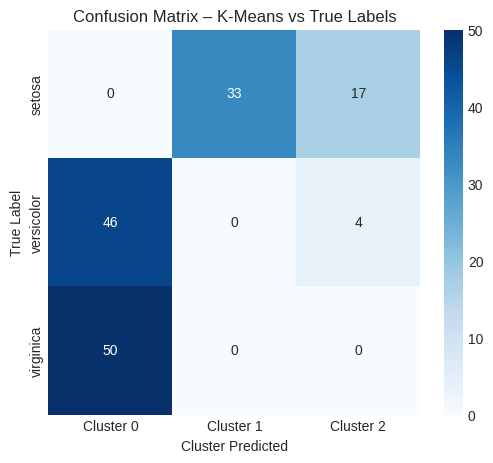

In [ ]:
# Tính Confusion Matrix
cm = confusion_matrix(y_true, y_kmeans)
ari_score = adjusted_rand_score(y_true, y_kmeans)

print("\nAdjusted Rand Index (ARI):", ari_score)

# =========================
# Vẽ heatmap Confusion Matrix
# =========================
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in range(cm.shape[1])],
            yticklabels=iris.target_names)
plt.xlabel('Cluster Predicted')
plt.ylabel('True Label')
plt.title('Confusion Matrix – K-Means vs True Labels')
plt.show()

/tmp/ipython-input-970674772.py:19: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-970674772.py:19: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-970674772.py:19: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/

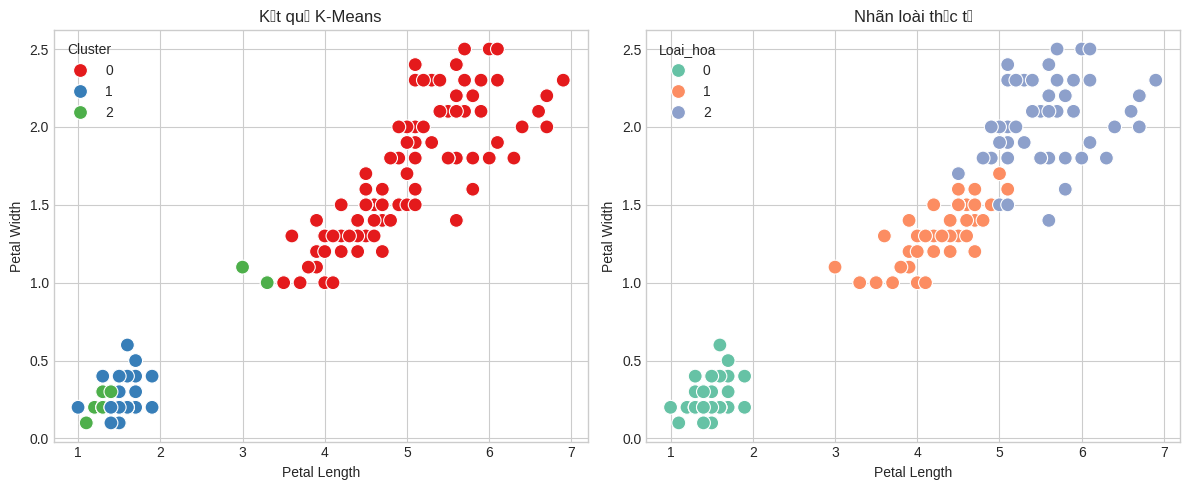

In [ ]:
plt.figure(figsize=(12,5))

# Nhãn phân cụm
plt.subplot(1,2,1)
sns.scatterplot(x=df['petal length (cm)'], y=df['petal width (cm)'],
                hue=df['Cluster'], palette='Set1', s=100)
plt.title("Kết quả K-Means")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

# Nhãn thực tế
plt.subplot(1,2,2)
sns.scatterplot(x=df['petal length (cm)'], y=df['petal width (cm)'],
                hue=df['Loai_hoa'], palette='Set2', s=100)
plt.title("Nhãn loài thực tế")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.tight_layout()
plt.show()